<a href="https://colab.research.google.com/github/me1-3/Emsc2010-A3/blob/main/Copy_of_a3_oxidised_nitrogen.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

##**1. Introduction:**


###**1.1 Western Port**

Western port is a large shallow embayment, which is It is surrounded by urban and agricultural lands, such that much of the natural landscape has been altered dramatically [3].

In my study of this location, I drew data forth from the 'EPA Western Port Water Quality Data 1990 - 2025' report to analyse how the local environmental  had changed over time due to man-made factors.

###**1.2 Data Set**

My original data set was sourced from this site: https://discover.data.vic.gov.au/dataset/epa-western-port-water-quality-data where observations where attemped to be made monthly, over the course of 35 years, from 1990 - 2025.

I cleaned the dataset to only contain the parameters that I was interested in examining: https://anu365-my.sharepoint.com/:x:/g/personal/u8216285_anu_edu_au/IQDP-tY6SH3uRbwQQZ3TutJZAX8T700pbnxJimA4K-waja4

###**1.3 Parameter**

Which in this case was Oxidised Nitrogen (NOx). As according to Melbourne Water's report 'Understanding the Western Port Environment', due to catchment run-off from local agriculture, drains and groundwater, there has been a significant increase in NOx. This is most prevelent in Corinella, as it sits in the eastern arm, of which receives a disportionately high amount of nutrient loads from the Bass River - furthermore due to eastern arm having longer residence times, NOx here accumulates more, rather than flushing quickly at other locations [3].

NOx, of which is the mixture of Nitric Oxide (NO) and Nitrogen Dioxide (NO<sub>2</sub>) is large threat towards both people and the environment as long term exposure or elevated levels damages the respitory track, and creates both smog and acid rain [4]. In more coastal environments such Western Port, it can contribute to nutrient pollution - fueling agal blooms [3].

Thereby my project seeks to examine these issues, asking the *question:*

###**1.4 Research Question & Hypothesis**

*How have concentrations of oxidised nitrogen changed in Western Port Victoria both time and what are their spatial distrubutions?*

With consideration to the extent that findings correlate to land useage and climate change?*

To which I hypothesise, in accordance to my background research in the topic that:

*The total percent of oxidised nitrogen at Western Port has increased due to human influence, and that Corinella will have significantly higher % of NOx.*


###**1.5 Map**

To give a frame of reference for the site's we are examining, I have included a map [2] of the area to visualise the spatial distribution  of the site:

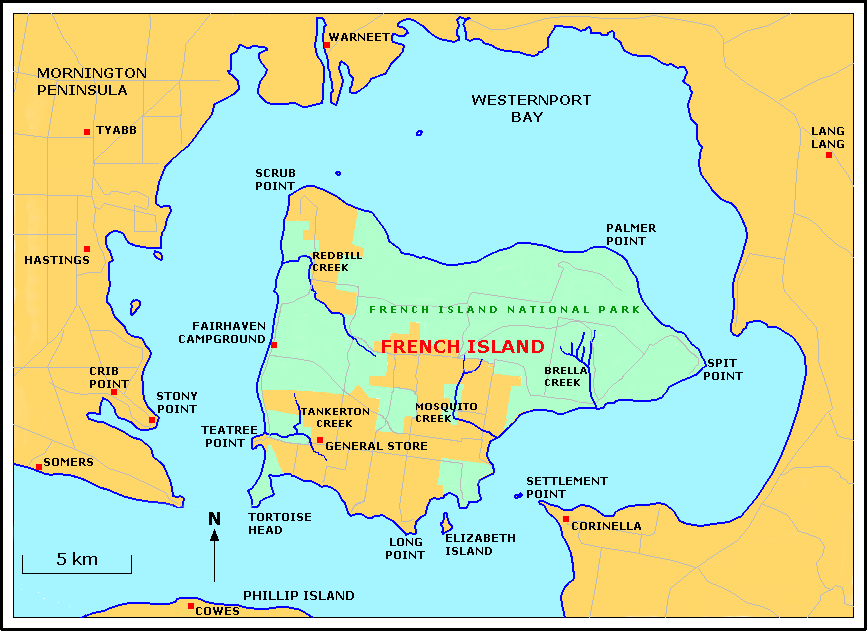

###**1.6 MetaData**

As well as provided the following Metadata to summarise the parameters chosen:

<p></p>
<table style="border-collapse: collapse; width: 474pt;" width="632">
<tbody>
<tr style="height: 14.25pt;">
<td class="xl118" style="width: 84pt; height: 14.25pt;" width="112" height="19">Parameter</td>
<td class="xl118" style="width: 114pt;" width="152">method_name</td>
<td class="xl118" style="width: 161pt;" width="215">parameter_name</td>
<td class="xl118" style="width: 115pt;" width="153">units</td>
</tr>
<tr style="height: 14.25pt;">
<td class="xl118" style="width: 84pt; height: 14.25pt;" width="112" height="19">N_NOX</td>
<td class="xl118" style="width: 114pt;" width="152">LAB</td>
<td class="xl118" style="width: 161pt;" width="215">oxidised nitrogen</td>
<td class="xl118" style="width: 115pt;" width="153">mg/L</td>
</tr>
</tbody>
</table><table width="735">
<tbody>
<tr>
<td width="87">site_id</td>
<td width="220">site_name_long</td>
<td width="138">site_name_short</td>
<td width="108">water_body</td>
<td width="98">latitude</td>
<td width="84">longitude</td>
</tr>
<tr>
<td>709</td>
<td>WESTERNPORT BAY&nbsp; MCU #709</td>
<td>Hastings</td>
<td>Western Port</td>
<td>-38.32913208</td>
<td>145.2371063</td>
</tr>
<tr>
<td>724</td>
<td>WESTERNPORT BAY&nbsp; MCU #724</td>
<td>Corinella</td>
<td>Western Port</td>
<td>-38.37223053</td>
<td>145.4830017</td>
</tr>
<tr>
<td>716</td>
<td>WESTERNPORT BAY&nbsp; MCU #716</td>
<td>Barralier Island</td>
<td>Western Port</td>
<td>-38.269905</td>
<td>145.314804</td>
</tr>
</tbody>
</table>
<p>&nbsp;</p>
<div id="gtx-trans" style="position: absolute; left: -31px; top: -20px;">&nbsp;</div>

#**2. Code Analysis:**

###**2.1 Importing Libraries, Loading and Clearing Data:**

I proceeded to install the necessary libaries needed for my analysis, and as well as load in the cleaned dataset that I was using, making to sure do a clean of the coloumns so they would run smoothly, & showing the first few rows to check.

In [497]:
#Install Bambi (BAyesian Model-Building Interface) for PyMC to run Bayesian statistical modeling
!pip install bambi

In [498]:
#Import core libraries used for modelling
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.ticker import MaxNLocator
import seaborn as sns
import bambi as bmb
import arviz as az
from scipy import stats
import pymc as pm
from matplotlib import colors as mcolors

In [499]:
# Load western port water quality data from my cleaned excel file
spreadsheet_name = "wpdata.xlsx"
worksheet_name = "Data"
df = pd.read_excel(spreadsheet_name, sheet_name=worksheet_name)

#clean the column names - strip spaces, convert to uppercase, replace spaces w/ underscores
df.columns = df.columns.str.strip().str.upper().str.replace(" ", "_")

#Show first 5 rows
df.head()

,SITE_NAME_SHORT,WATER_BODY,DATE,CHL_A,COLUMN2,DO_MG,SAL,DO_SAT,TEMPERATURE,PH,...,COLUMN1,TYPE,COLUMN3,COLUMN4,TEMP,COLUMN9,COLUMN5,COLUMN6,COLUMN8,COLUMN7
0,Hastings,Western Port,1990-02-28,1.30,2.0,7.18,36.383,100.980,21.70,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,Barralier Island,Western Port,1990-02-28,1.45,2.0,6.97,36.643,98.943,22.20,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,Corinella,Western Port,1990-02-28,1.68,1.0,6.33,37.221,91.129,22.80,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,Corinella,Western Port,1990-04-03,1.48,0.5,7.21,37.391,95.204,18.00,8.1,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,Hastings,Western Port,1990-04-04,1.30,2.0,7.11,36.626,95.069,18.85,8.2,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


###**2.2 Site selection + Time Conversion:**


Here I counted the number of observations of NOx made at each site, as there were only 3 total sites, I chose to keep all 3 and isolate them against each other - This way later I could analyse Hastings and Barralier Island against Corinella, to see if my assumption that Corinella would be higher than the two other Loactions, As well as plot the overall trend of Western Port.

In addition, I converted the date time to a decimal year such that code could read it, and did further data cleaning, removing any values that were negative, as you can't get them and are a source of error.

In [500]:
#count the num. of observations per site
df["SITE_NAME_SHORT"].value_counts()

,count
SITE_NAME_SHORT,
Corinella,385
Hastings,380
Barralier Island,265


In [501]:
#Choosing sites with the most observations
loc_types = ["Corinella", "Hastings", "Barralier Island"]
loc_1, loc_2, loc_3 = loc_types
print("Locations used:", loc_types)

Locations used: ['Corinella', 'Hastings', 'Barralier Island']


In [502]:
#Converted the date-time into a usable format - aka decimal year
df["TIME_FLOAT"] = df["DATE"].dt.year + (df["DATE"].dt.month - 1) / 12

#Defined column names such that I could parameters easily if needed
loc_col = "SITE_NAME_SHORT"
x_col = "TIME_FLOAT"
y_col = "N_NOX"

#Filtered to the three locations, so could analyse sites against each other and filtered keep only the needed columns
data = df[df[loc_col].isin([loc_1, loc_2, loc_3])].copy()
data = data[[loc_col, x_col, y_col]].dropna()

#Remove non-positive NOx values (as you cant remove more than whats available)
data = data[data[y_col] > 0].copy()

###**2.3 Initial Exploratory Analysis:**

This scatter plot shpws the 3 sites each with a substaintail variabilty in NOx. Furthmore, Corinella shows higher and more extreme values in  comparison to the other two sites. This plot is an early indicator of a small rise away from 0 in NOx over the past 3 decades, but the pattern is very noisy.

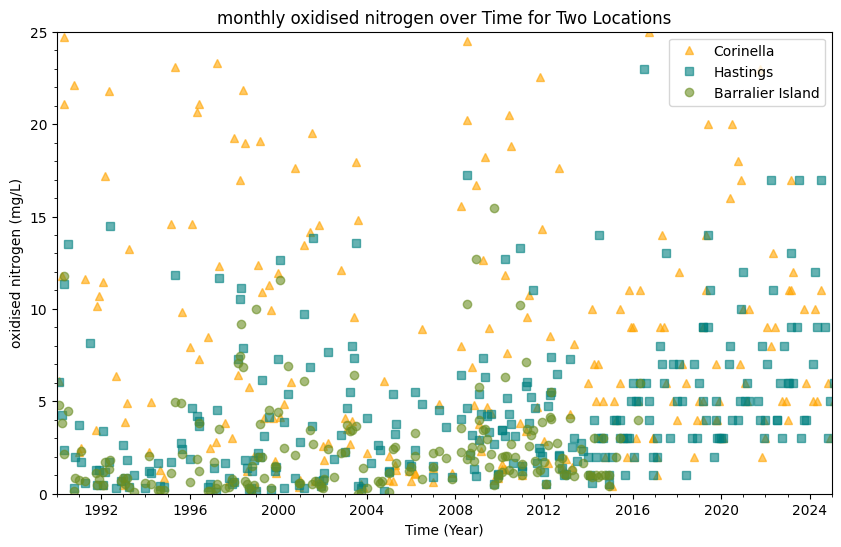

In [552]:
#Intial scatter plot of NOx over time - all 3 sites combined

#Assign each site a colour and symbol
colors = ["orange", "teal", "olivedrab"]
symbols =  ["^", "s", "o"]

#Scatter plot :)
plt.figure(figsize=(10, 6))
for loc, c, marker in zip([loc_1, loc_2, loc_3], colors, symbols):
    subset = data[data[loc_col] == loc]
    plt.plot(subset[x_col],
             subset[y_col],
             marker,
             alpha=0.6,
             color=c,
             label=loc)

plt.gca().xaxis.set_major_locator(MaxNLocator(integer=True))
plt.xlabel("Time (Year)")
plt.ylabel("oxidised nitrogen (mg/L)")
plt.legend()
plt.ylim(0, 25) #you cant get negatives
plt.xlim(1990, 2025)
plt.minorticks_on()
plt.title("monthly oxidised nitrogen over Time for Two Locations")
plt.show()


###**2.4 Bootstraping:**

Due to the relativly small amount of observations within the dataset, I decide to Bootstrap my data to create many more simulated datasets, such that I could get a good estimate for the confidence interval and establish a mean NOx both the cumulative sites & one for each site.

- I estimated the overall mean & its uncertainty without assuming normality, to set a baseline for my later comparisons and regression modelling.

- I did one for both the combined and individual.

Overall, when examing the individual bootstraps you can see a clear pattern where Corinella has a much higher mean than the others, illustraing a stronger concentration at the site. This helps to inform the spactial distrubtion of NOx at Western Port.

####**2.4.1 Bootstrap of All Sites**

In [504]:
#Use all NOx values from the three locations
X = data[y_col].values

#Setting a random seed & drawing random samples
np.random.seed(42)
B = np.random.choice(X, size=(len(X), 1000), replace=True)
bar = np.mean(B, axis=0)
print("Bootstrap means created:", bar.shape)

Bootstrap means created: (1000,)


95% confidence interval: [ 8.23905585 11.66436458]


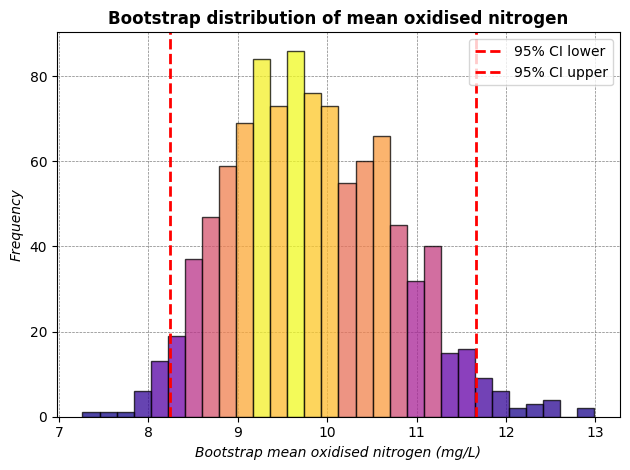

In [505]:
#Plotting the bootsrap distribution of mean NOx!!!
fig, ax = plt.subplots(tight_layout=True)
n, bins, patches = ax.hist(
    bar,
    bins=30,
    edgecolor="k",
    alpha=0.75
)

#MADE MORE COLOURFUL & DETAILED THAN OTHER BC ITS THE BASELINE
#Colour by frequency
fracs = n / n.max()
norm = mcolors.Normalize(fracs.min(), fracs.max())
for thisfrac, thispatch in zip(fracs, patches):
    color = plt.cm.plasma(norm(thisfrac))
    thispatch.set_facecolor(color)
#Establish grid
ax.set_axisbelow(True)
ax.grid(color="gray", linestyle="dashed", linewidth=0.5)

#Label
plt.xlabel("Bootstrap mean oxidised nitrogen (mg/L)", style="italic")
plt.ylabel("Frequency", style="italic")
plt.title("Bootstrap distribution of mean oxidised nitrogen", fontweight="bold")

#Confidence interval
ci = np.percentile(bar, [2.5, 97.5])
print("95% confidence interval:", ci)

#Show
plt.axvline(ci[0], color="red", linestyle="dashed", linewidth=2, label="95% CI lower")
plt.axvline(ci[1], color="red", linestyle="dashed", linewidth=2, label="95% CI upper")
plt.legend()
plt.show()


####**2.4.2 Bootstrap Indiv.**

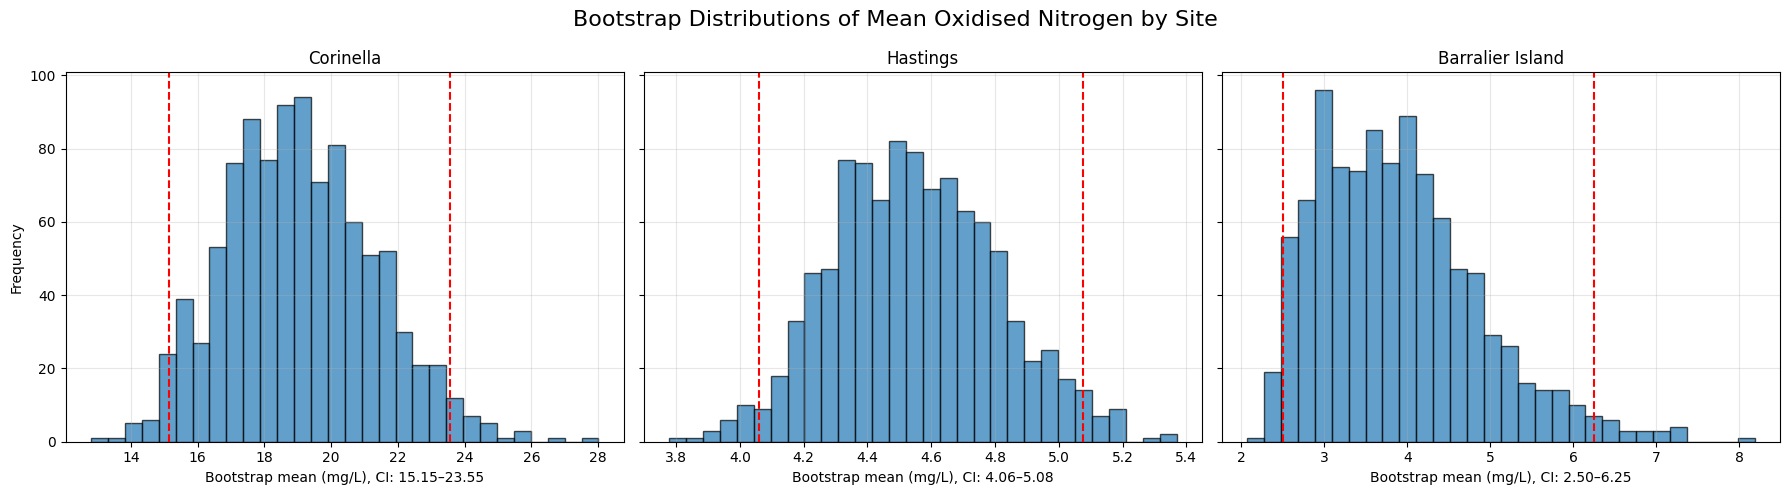

In [506]:
#Bootstrap analysis for each site separately

#Setting seed
np.random.seed(42)
#Establish locations
sites = [loc_1, loc_2, loc_3]

#plot each side by side via loop
fig, axes = plt.subplots(1, 3, figsize=(18, 5), sharey=True)

for ax, loc in zip(axes, sites):
    #get values of site in loop
    site_values = data[data[loc_col] == loc][y_col].dropna().values
    #resampling of site in loop
    B = np.random.choice(site_values, size=(len(site_values), 1000), replace=True)
    boot_means = np.mean(B, axis=0)
    #95% Confidence interval
    ci_low, ci_high = np.percentile(boot_means, [2.5, 97.5])
    #Plot :)
    ax.hist(boot_means, bins=30, edgecolor="k", alpha=0.7)
    ax.axvline(ci_low, color="red", linestyle="--")
    ax.axvline(ci_high, color="red", linestyle="--")
#each plot labels & grids
    ax.set_title(f"{loc}")
    ax.set_xlabel(f"Bootstrap mean (mg/L), CI: {ci_low:.2f}–{ci_high:.2f}")
    ax.grid(alpha=0.3)

#y axis label
axes[0].set_ylabel("Frequency")
#show
plt.suptitle("Bootstrap Distributions of Mean Oxidised Nitrogen by Site", fontsize=16)
plt.tight_layout()
plt.show()

###**2.5 Hypothesis Testing:**

After using bootstraping to examine where the mean might lay for the combined, as well as observed the difference in CI across individual, I want to examine if there has been a increase in mean NOx across the whole Western Port, from about the halfway point that the reasearch was observed; 1990 - 2007, and 2007 - 2025.

After defining my cut-off dates, I calculated the bayesian models for both the early and recent periods, defining my prior mean as 9.5 mg/L from our combined bootstrap. Where I got the prior mean from our bootstraping analsysis, and used a  sigma of 2 for uncertainty.

In the testing done below, we see that the posterior distrubtion is mostly centered 0, and that when we calculated a 95% HDI interval our values mostly fell with it's range. Furthermore in calculating the probabilty that the recent mean is > early mean we got 0.99,  a 99% chance of increase over time, an incredbly strong chance. Overall these results helped to support our hypothesis over an increase in NOx over time.

####**2.5.1 Bayesian models:**

CUT OFF DATES -->

In [507]:
#cut-off dates:
#defining my early years
data_early = df[(df[x_col] <= 2007)][y_col].dropna()
data_early = data_early[data_early>0]

#defining my recent years
data_recent = df[(df[x_col] > 2007)][y_col].dropna()
data_recent = data_recent[data_recent>0]

EARLY -->

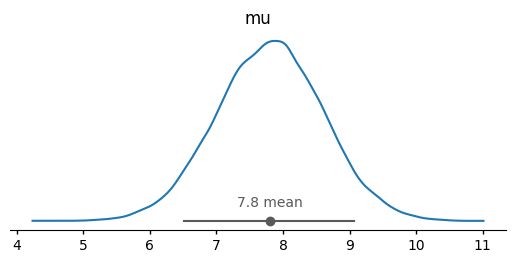

In [556]:
#Baysesian model for early period

with pm.Model() as early_model:
  #prior for the mean
  mu = pm.Normal("mu", mu = 9.5, sigma = 2)
  #prior for the stanard deviation
  sigma = pm.HalfNormal ("sigma", sigma = 2)
  # likleiood
  obs = pm.Normal ("obs", mu = mu, sigma = sigma, observed = data_early)
  #sample from the posterior
  trace_early = pm.sample(20000, tune = 2000, return_inferencedata = True, progressbar = False)

#Plot the posterior dist for the mean
az.plot_dist(trace_early, var_names=["mu"])

RECENT -->

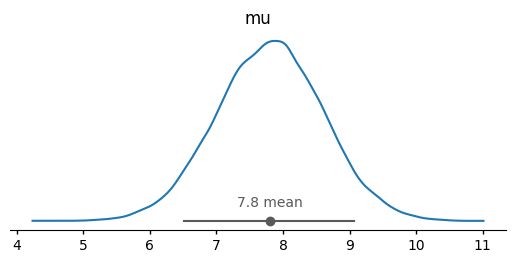

In [557]:
#Baysesian model for early period

with pm.Model() as recent_model:
  #prior for mean
  mu = pm.Normal("mu", mu = 9.5, sigma = 2)
  #prior for standard deviation
  sigma = pm.HalfNormal ("sigma", sigma = 2)
  #likelihood
  obs = pm.Normal ("obs", mu = mu, sigma = sigma, observed = data_recent)
  #sample from the posterior
  trace_recent = pm.sample(20000, tune = 2000, return_inferencedata = True, progressbar = False)

  #Plot the posterior dist for the mean
  az.plot_dist(trace_early, var_names=["mu"])

####**2.5.2 Posterior Difference:**

In [558]:
#extract samples from both models
mu_samples_early = trace_early.posterior["mu"].values.flatten()
mu_samples_recent = trace_recent.posterior["mu"].values.flatten()

#diff in means, recent - early
mu_diff = mu_samples_recent - mu_samples_early

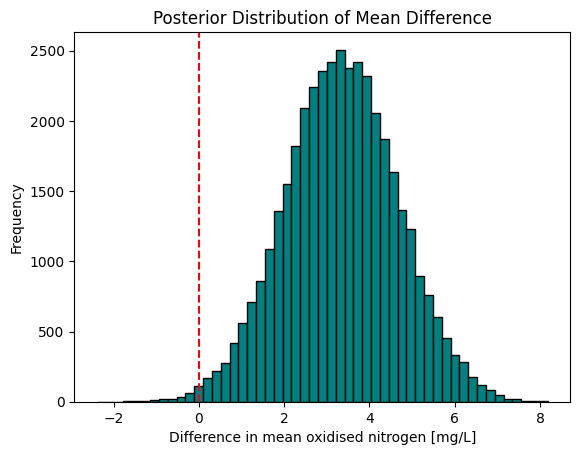

In [559]:
#histogram
plt.hist(mu_diff, bins = 51, color="teal", edgecolor="k")
#zero reference line
plt.axvline(0, color="red", linestyle="dashed")
#labels
plt.xlabel("Difference in mean oxidised nitrogen [mg/L]")
plt.ylabel("Frequency")
plt.title("Posterior Distribution of Mean Difference")
#show
plt.show() #show plot

####**2.5.3 Probanilty of Increase:**

In [560]:
#calc 95% HDI
az.hdi(mu_diff, prob = 0.95)

array([0.75505097, 5.9455693 ])

In [561]:
#Calc that prob of recent mean > early mean
np.mean(mu_diff > 0)

np.float64(0.994775)

###**2.6 Bayesian Regression Analysis:**

Here I have moved on to analyse NOx's trend over time, plotting both each site ontop of each other to get an estimate for the spatial distrubtuion and combined for an overall temporal one.

First I scaled time, and created my polynomial terms. I then used these terms to compare them against each other to find the best modal to use for my regression analysis, which was the linear modal (rank 0) for oxidised nitrogen across the three locations. The linear model helps to provide a simple summary of the trend of the data. I then ran my priors for my linear modal. They were extremly broad and centered around 0, which reflects weak assumptions about the NOx concentration over time. The posterior plots for my regression models, when examing the MCMC chains had good overlap and convergence.

I then established the predictive ranges for each and their individual HDIs for each site before using that information and plotting a combined verison onto one plot. The postier represented the models best estimation for where teh true mean could lie, and there was a trend where the uncerntity increased as the linear model approached the limits of the x-axis, as well as dipping below the x-axis a limitation of the model.

However when we look at 2.5.5, our individual plot we see interesting trends. First of all the Corinella Site has a much higher % of NOx in comparsion to the other sites. However what is fascinating is that barralier Island actualy decreases over time in comparsion to Hastings which increases, crossing over each other around 2005. This *disproves* my hypothesis, indicating that there are others factors at play effecting the NOx content.

####**2.6.1 Scaling time & creating polynomial terms:**

In [514]:
#scale time for numerical stability
data["x_scaled"] = (data[x_col] - data[x_col].mean()) / data[x_col].std()

#quadric and cubic terms
data["x2_scaled"] = data["x_scaled"] ** 2
data["x3_scaled"] = data["x_scaled"] ** 3

####**2.6.2 fit linear, quadratic, cubic models & compare**

In [515]:
#linear - 1st order polynomial
model_linear = bmb.Model(f"{y_col} ~ x_scaled * {loc_col}", data)
idata_linear = model_linear.fit(idata_kwargs={"log_likelihood": True}, progressbar=False)

#quadratic - 2nd order polynomial
model_quadratic = bmb.Model(f"{y_col} ~ x_scaled + x2_scaled * {loc_col}", data)
idata_quadratic = model_quadratic.fit(idata_kwargs={"log_likelihood": True}, progressbar=False)

#cubic - 3rd order polynomial
model_cubic = bmb.Model(f"{y_col} ~ x_scaled + x2_scaled + x3_scaled * {loc_col}", data)
idata_cubic = model_cubic.fit(idata_kwargs={"log_likelihood": True}, progressbar=False)

#false progress bars so that once in the Github it wasn't invalid

/usr/local/lib/python3.12/dist-packages/pymc/sampling/mcmc.py:1163: FutureWarning: Passing `log_likelihood` via `idata_kwargs` is deprecated and will be removed in future versions. Call `pm.compute_log_likelihood(idata)` instead.
  return _sample_return(
/usr/local/lib/python3.12/dist-packages/pymc/sampling/mcmc.py:1163: FutureWarning: Passing `log_likelihood` via `idata_kwargs` is deprecated and will be removed in future versions. Call `pm.compute_log_likelihood(idata)` instead.
  return _sample_return(
/usr/local/lib/python3.12/dist-packages/pymc/sampling/mcmc.py:1163: FutureWarning: Passing `log_likelihood` via `idata_kwargs` is deprecated and will be removed in future versions. Call `pm.compute_log_likelihood(idata)` instead.
  return _sample_return(


In [516]:
#compare models using arviz, 0 is best model
cmp = az.compare(
    {"linear": idata_linear, "quadratic": idata_quadratic, "cubic": idata_cubic},
    method="BB-pseudo-BMA"
)
cmp

/usr/local/lib/python3.12/dist-packages/arviz_stats/loo/helper_loo.py:1146: UserWarning: Estimated shape parameter of Pareto distribution is greater than 0.70 for one or more samples. You should consider using a more robust model, this is because importance sampling is less likely to work well if the marginal posterior and LOO posterior are very different. This is more likely to happen with a non-robust model and highly influential observations.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/arviz_stats/loo/helper_loo.py:1146: UserWarning: Estimated shape parameter of Pareto distribution is greater than 0.70 for one or more samples. You should consider using a more robust model, this is because importance sampling is less likely to work well if the marginal posterior and LOO posterior are very different. This is more likely to happen with a non-robust model and highly influential observations.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/arviz_stats/loo/helper_loo

,rank,elpd,p,elpd_diff,weight,se,dse,warning
linear,0,-3500.0,39.3,0.0,0.56,150.0,0.0,True
cubic,1,-3500.0,44.5,-1.0,0.38,160.0,2.4,True
quadratic,2,-3600.0,41.4,-3.0,0.06,160.0,2.0,True


####**2.6.3 priors and posteriors:**

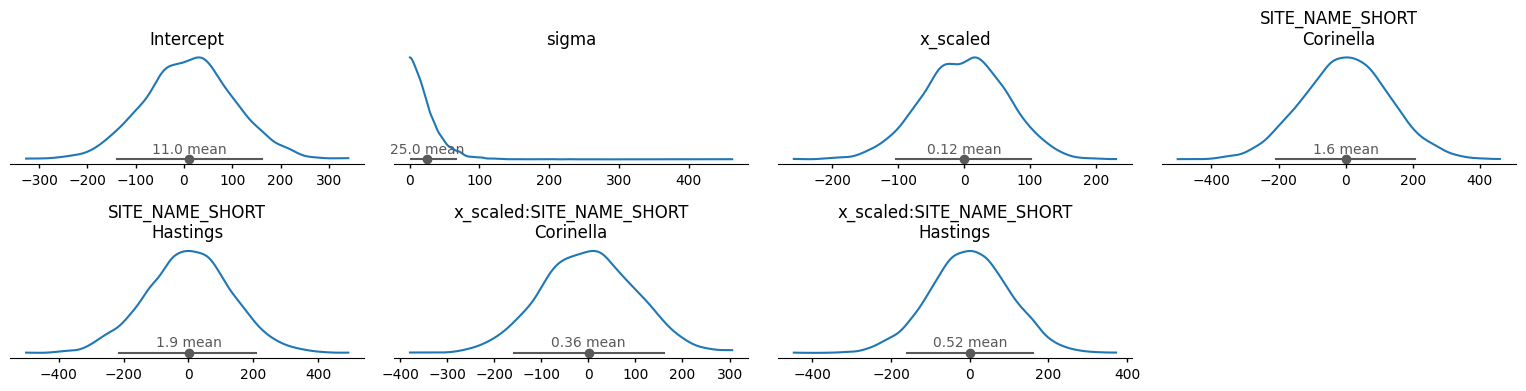

In [525]:
#uplot priors used by bambi
model_linear.plot_priors()
plt.tight_layout()
plt.show()

 Priors for the linear regression model. They are incredibly broad and centred around zero, reflecting weak prior assumptions about the realtionship oxidised nitrogen over time.

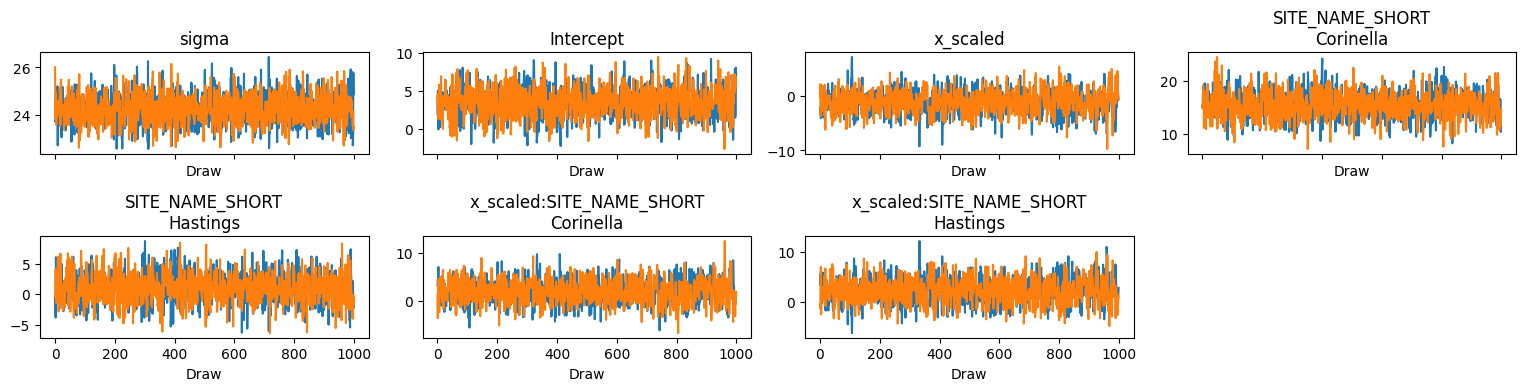

In [526]:
#plot sampled posterior distrubtions
az.plot_trace(idata_linear)
plt.tight_layout()
plt.show()

####**2.6.4 Predictive ranges + HDIs for each Loc:**

In [528]:
#predict across a number of years, 1990 - 2025
x_range = np.linspace(data[x_col].min(), data[x_col].max(), 1000)
x_range_scaled = (x_range - data[x_col].mean()) / data[x_col].std()
#define scaled 2nd and 3rd order polynomial terms for range
x2_range_scaled = x_range_scaled ** 2
x3_range_scaled = x_range_scaled ** 3

In [553]:
#new dataframe predictive for location 1
new_data_loc1 = pd.DataFrame({
    "x_scaled": x_range_scaled,
    "x2_scaled": x2_range_scaled,
    "x3_scaled": x3_range_scaled,
    loc_col: loc_1
})
idata_pred_loc1_params = model_linear.predict(idata_linear,
                                             data=new_data_loc1,
                                             kind="response_params",
                                             inplace=False)
idata_pred_loc1_resp = model_linear.predict(idata_linear,
                                           data=new_data_loc1,
                                           kind="response",
                                           inplace=False)
#predict dist. of regression lines each yr
mu_draws_loc1 = idata_pred_loc1_params.posterior["mu"].stack(draws=("chain","draw")).values.T
pps_draws_loc1 = idata_pred_loc1_resp.posterior_predictive[y_col].stack(draws=("chain","draw")).values.T
#compute HDI and mean of post. predict dist

posterior_mean_loc1 = pps_draws_loc1.mean(axis=0)
hdi_mean_loc1 = az.hdi(mu_draws_loc1, prob=0.95, axis=0)
hdi_pps_loc1 = az.hdi(pps_draws_loc1, prob=0.95, axis=0)

In [530]:
#predictions for location 2
new_data_loc2 = pd.DataFrame({
    "x_scaled": x_range_scaled,
    "x2_scaled": x2_range_scaled,
    "x3_scaled": x3_range_scaled,
    loc_col: loc_2
})
idata_pred_loc2_params = model_linear.predict(idata_linear,
                                             data=new_data_loc2,
                                             kind="response_params",
                                             inplace=False)
idata_pred_loc2_resp = model_linear.predict(idata_linear,
                                           data=new_data_loc2,
                                           kind="response",
                                           inplace=False)
#predict dist. of regression lines each yr
mu_draws_loc2 = idata_pred_loc2_params.posterior["mu"].stack(draws=("chain","draw")).values.T
pps_draws_loc2 = idata_pred_loc2_resp.posterior_predictive[y_col].stack(draws=("chain","draw")).values.T
#compute HDI and mean of post. predict dist
posterior_mean_loc2 = pps_draws_loc2.mean(axis=0)
hdi_mean_loc2 = az.hdi(mu_draws_loc2, prob=0.95, axis=0)
hdi_pps_loc2 = az.hdi(pps_draws_loc2, prob=0.95, axis=0)

In [531]:
# Predictions for location 3
new_data_loc3 = pd.DataFrame({
    "x_scaled": x_range_scaled,
    "x2_scaled": x2_range_scaled,
    "x3_scaled": x3_range_scaled,
    loc_col: loc_3
})
idata_pred_loc3_params = model_linear.predict(idata_linear,
                                             data=new_data_loc3,
                                             kind="response_params",
                                             inplace=False)
idata_pred_loc3_resp = model_linear.predict(idata_linear,
                                           data=new_data_loc3,
                                           kind="response",
                                           inplace=False)
#predict dist. of regression lines each yr
mu_draws_loc3 = idata_pred_loc3_params.posterior["mu"].stack(draws=("chain","draw")).values.T
pps_draws_loc3 = idata_pred_loc3_resp.posterior_predictive[y_col].stack(draws=("chain","draw")).values.T
#compute HDI and mean of post. predict dist
posterior_mean_loc3 = pps_draws_loc3.mean(axis=0)
hdi_mean_loc3 = az.hdi(mu_draws_loc3, prob=0.95, axis=0)
hdi_pps_loc3 = az.hdi(pps_draws_loc3, prob=0.95, axis=0)

####**2.6.5 Indiv. comparsion plot**

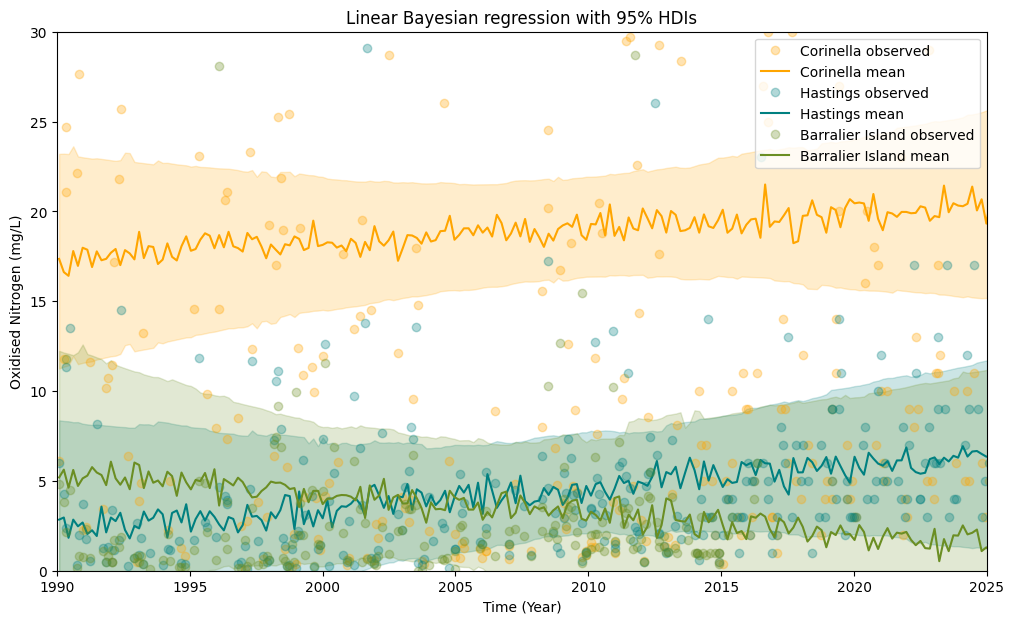

In [564]:
plt.figure(figsize=(12, 7))

for loc, c, mean, hdi_m in [
    (loc_1, colors[0], posterior_mean_loc1, hdi_mean_loc1),
    (loc_2, colors[1], posterior_mean_loc2, hdi_mean_loc2),
    (loc_3, colors[2], posterior_mean_loc3, hdi_mean_loc3),
]:
    subset = data[data[loc_col] == loc]
    plt.plot(subset[x_col], subset[y_col], "o", color=c, alpha=0.3, label=f"{loc} observed")
    plt.plot(x_range, mean, color=c, label=f"{loc} mean")
    plt.fill_between(x_range, hdi_m[:, 0], hdi_m[:, 1], alpha=0.2, color=c)
plt.ylim(0, 30)
plt.xlim(1990, 2025)
plt.xlabel("Time (Year)")
plt.ylabel("Oxidised Nitrogen (mg/L)")
plt.title("Linear Bayesian regression with 95% HDIs")
plt.legend(loc="upper right")
plt.show()

#**3. Conclusion:**

###**3.1 Findings:**

Overall by using a Bootstrap analysis of my data, we discovered that the average NOx concentration for all the combined sites was around 9.5 - with individual bootraps of each site showing a severe dicthomy in NOx concetration, where Corinella had a much higher content, compared to Hastings and Barralier Island. We then used Hypothises testing to check if there was trend of NOx increase over time, which (using the bootrap as our posteior mean) found a 99% chance of an increase. This increase further reflected in Bayesian Regressian analysis. However here we noticed that Barralier actually had a decresing amount of NOx overtime, which disproved my hypothesis.


###**3.2 Limitations & Uncertainties:**
However these findings have a degree of uncertity to them, despite trying to clean the data of negative values there are strill uncerntainty trends below the x-axis, which having a negative NOx is impossible. Furthnore the sampling of my data was attempted to be "Monthly (where possible)" [1] but was inconsistent. Furthermore the large amount of noise from the Corinella had a strong influence on both bootstrap and regression results. Furthmore for out forays into spatial distrubiton, the dataset only had 3 sites, which limited generalisation. My wide HDI aslo relfected a high amount of variabilty with in NOx.

###**3.3 Implications:**

Overall, in adressing elements of my hypothesis we can state whilst there is a gradualr increasing trend in NOx it is highly dependant on location. We have already adressed how local infrasture from  nearby Corinella has polluted the surrounding water quality, and the same can be stated of the Hastings siite, which also is in a built-up environment. These factors actually explain why we see a decrease in NOx at barrelier Island, as it off shore, above scrub point on the map [2], next to the French Island National Park and thus less built up and can more easily recover. We, in adressing our research question can therefore state that urban infrastructure is indictive of a rise in NOx.

#**References:**


1. EPA Western Port Water Quality Data 1990 - 2025 - Victorian Government Data Directory. (2025). Vic.gov.au. https://discover.data.vic.gov.au/dataset/epa-western-port-water-quality-data

2. French Island National Park. (n.d.). Western Port [Map]. Wikimedia Commons. https://en.wikipedia.org/wiki/Western_Port#/media/File:French_Island_National_Park.png


3. Melbourne Water. (2011). Understanding the Western Port Environment A summary of current knowledge and priorities for future research. https://www.melbournewater.com.au/sites/default/files/2018-02/Understanding_the_Western_Port_Environment_0.pdf

4. Queensland Government. (2013, August 29). Nitrogen oxides | Air pollutants. Www.qld.gov.au; Queensland Government. https://www.qld.gov.au/environment/management/monitoring/air/air-pollution/pollutants/nitrogen-oxides